In [1]:
from langchain_groq import ChatGroq
import os
llm=ChatGroq(model_name="llama-3.1-8b-instant")
llm.invoke("hi").content

f:\Conda\envs\langgraph_tut_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'How can I assist you today?'

In [2]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"  # small & fast
)

In [3]:

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_chroma import Chroma                                    # ✅ updated import
from langchain_text_splitters import RecursiveCharacterTextSplitter    # ✅ updated import

In [4]:
loader2=DirectoryLoader("../data2",glob="./*.txt",loader_cls=TextLoader)
docs2=loader2.load()

text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)
new_docs2 = text_splitter.split_documents(documents=docs2)
doc_strings2 = [doc.page_content for doc in new_docs2]

In [5]:
db2 = Chroma.from_documents(new_docs2, embeddings)
retriever2 = db2.as_retriever(search_kwargs={"k": 3})

In [6]:
query = "Tell me about India's Industrial Growth?"
docs = retriever2.invoke(query)

In [7]:
for doc in docs:
    print(doc)

page_content='India’s industrial growth has outpaced expectations, raising hopes that the economy will avoid a' metadata={'source': '..\\data2\\indian_economy.txt'}
page_content='Industrial Revival and Economic Optimism for India' metadata={'source': '..\\data2\\indian_economy.txt'}
page_content='for India’s economy. “We are encouraged by the steady rise in domestic consumption and industrial' metadata={'source': '..\\data2\\indian_economy.txt'}


In [9]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate  # ✅ updated import

In [10]:
class AgentState(TypedDict):
    # The 'messages' field should be a sequence of strings, and we annotate it with 'operator.add'
    # This implies we might want to "add" new messages to the sequence later
    messages: Annotated[Sequence[BaseMessage], operator.add]

## Putting It All Together:

In [11]:
from pydantic import BaseModel , Field
class TopicSelectionParser(BaseModel):
    Topic: str = Field(description='Selected Topic')
    Reasoning: str = Field(description='Reasoning behind topic selection')

In [13]:
from langchain_core.output_parsers import PydanticOutputParser  # ✅ updated import

parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [14]:
print(parser.get_format_instructions())

The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
```


In [26]:
def function_1(state):
    message = state["messages"]
    question = message[-1]
    print(question)
    
    template = """
    Your task is to classify the given user query into one of the following categories: [India, Not Related]. 
    Respond ONLY with a valid JSON object as per the format instructions below. Do not add any extra text.

    User query: {question}
    {format_instructions}
    """
    
    prompt = PromptTemplate(
        template=template,
        input_variables=["question"],
        partial_variables={
            "format_instructions": parser.get_format_instructions()
        }
    )
    chain = prompt | llm | parser
    
    response = chain.invoke({
        "question": question,
        "format_instructions": parser.get_format_instructions()
    })

    print(response)
    return {"messages": [response.Topic]}

In [27]:
template="""
    Your task is to classify the given user query into one of the following categories: [India, Not Related]. 
    Only respond with the category name and nothing else.

    User query: "Tell me about India's Industrial Growth"
    The output should be formatted as a JSON instance that conforms to the JSON schema below.

    As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
    the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

    Here is the output schema:
    ```
    {"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
        """

In [28]:

state={"messages": ["Tell me about India's Industrial Growth"]}

In [29]:
function_1(state)

Tell me about India's Industrial Growth
Topic='India' Reasoning="The query is about India's Industrial Growth, indicating a specific interest in India."


{'messages': ['India']}

In [30]:
def router(state):
    print('-> Router ->')
    
    messages = state["messages"]
    last_message = messages[-1]
    print(last_message)
    if 'India' in last_message:
        return 'RAG Call'
    else:
        return 'LLM Call'

In [38]:
def function_2(state):
    print('-> Calling RAG ->')
    messages = state['messages']
    question = messages[0] ## Fetching the user question
    print(question)

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)
    
    print(prompt)

    retrieval_chain = (
        {"context": retriever2, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    return  {"messages": [result]}

In [39]:
def function_3(state):
    print('-> Calling LLM ->')

    messages = state['messages']
    question = messages[0] ## Fetching the user question

    # Normal LLM call
    complete_query = "Anwer the follow question with your knowledge of the real world. Following is the user question: " + question
    response = llm.invoke(complete_query)
    return {"messages": [response.content]}

In [33]:

AgentState

__main__.AgentState

In [40]:
from langgraph.graph import StateGraph,END

workflow5 = StateGraph(AgentState) ### StateGraph with AgentState


workflow5.add_node("agent", function_1)

workflow5.add_node("RAG", function_2)

workflow5.add_node("LLM", function_3)


workflow5.set_entry_point("agent")

workflow5.add_conditional_edges(
    "agent",
    
    
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)

workflow5.add_edge("RAG",END)


workflow5.add_edge("LLM",END)


app5=workflow5.compile()

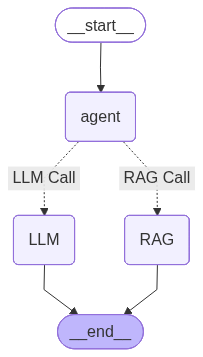

In [41]:
from IPython.display import Image, display

try:
    display(Image(app5.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [42]:
inputs = {"messages": ["Tell me about India's Industrial Growth"]}

output = app5.invoke(inputs)

Tell me about India's Industrial Growth
Topic='India' Reasoning="The query is about India's Industrial Growth, indicating a topic related to India"
-> Router ->
India
-> Calling RAG ->
Tell me about India's Industrial Growth
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


In [43]:

output

{'messages': ["Tell me about India's Industrial Growth",
  'India',
  "India's industrial growth has outpaced expectations."]}

In [44]:
inputs = {"messages": ["Tell me about first prime minister of india?"]}

output = app5.invoke(inputs)

Tell me about first prime minister of india?
Topic='India' Reasoning='The query is about the first prime minister of India.'
-> Router ->
India
-> Calling RAG ->
Tell me about first prime minister of india?
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


In [45]:
inputs = {"messages": ["who build the Taj Mahal?"]}
output = app5.invoke(inputs)

who build the Taj Mahal?
Topic='India' Reasoning='The Taj Mahal is a famous monument in India.'
-> Router ->
India
-> Calling RAG ->
who build the Taj Mahal?
input_variables=['context', 'question'] input_types={} partial_variables={} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n    {context}\n\n    Question: {question}\n    '), additional_kwargs={})]


In [46]:
output

{'messages': ['who build the Taj Mahal?',
  'India',
  "I can't find any information about the building of the Taj Mahal in the provided context. The context appears to be about the Indian economy."]}

In [48]:
inputs = {"messages": ["Hi, how are you?"]}
output = app5.invoke(inputs)

Hi, how are you?
Topic='Not Related' Reasoning='The query is a general greeting and does not mention any specific topic related to India.'
-> Router ->
Not Related
-> Calling LLM ->


In [49]:
output

{'messages': ['Hi, how are you?',
  'Not Related',
  "I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist with any questions or tasks you may have. How about you? How's your day going?"]}